# Fraud Detection — Explainability

**Prerequisite:** none — self-contained
**Companion to:** `06-rule-optimisation.ipynb`

## Why this matters operationally

A flag an analyst cannot interrogate is a flag they learn to ignore.

The rules layer is inherently explainable: *"flagged because V14 < -3.5."* The Random
Forest is not — it outputs 0.87 and no reason. If the model is going to replace rules in
the review queue (and notebook 06 showed it is roughly 3x cheaper), it needs to be at
least as reviewable, or adoption fails for social reasons rather than technical ones.

SHAP gives per-prediction attributions: for *this* transaction, which features pushed the
score up, and by how much.

## A second purpose: validating the rules

The anomaly rule uses V14, V4 and V12 — cutoffs chosen by eyeballing the EDA. If SHAP
independently ranks those same features at the top, that is convergent evidence the
feature selection was sound rather than lucky. If it does not, that is worth knowing too.

## Steps
1. Train the model
2. Global attribution — which features drive fraud detection overall
3. Cross-check against the rule features
4. Local attribution — explain individual flagged transactions
5. Build the analyst-facing explanation an operations team would actually receive

## Step 1: Setup

In [11]:
# SHAP is not in requirements.txt by default — install once if needed
try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'shap', '--quiet'])
    import shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub, os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
os.makedirs('plots', exist_ok=True)
print(f'shap {shap.__version__} ready.')

shap 0.47.2 ready.


In [12]:
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
df = pd.read_csv(os.path.join(path, 'creditcard.csv'))
df.insert(0, 'transaction_id', range(1, len(df) + 1))

sc = StandardScaler()
df['Amount_scaled'] = sc.fit_transform(df[['Amount']])
df['Time_scaled']   = sc.fit_transform(df[['Time']])
feature_cols = [f'V{i}' for i in range(1, 29)] + ['Amount_scaled', 'Time_scaled']

X, y, amounts = df[feature_cols], df['Class'], df['Amount']
X_tr, X_te, y_tr, y_te, amt_tr, amt_te, id_tr, id_te = train_test_split(
    X, y, amounts, df['transaction_id'], test_size=0.2, random_state=42, stratify=y)

rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                            random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
proba_te = rf.predict_proba(X_te)[:, 1]
print(f'Model trained. Test set: {len(X_te):,} transactions, {int(y_te.sum())} frauds.')

Model trained. Test set: 56,962 transactions, 98 frauds.


## Step 2: Global attribution

TreeSHAP is exact for tree ensembles but scales with the data, so we sample. All frauds
are kept (there are few and they are the interesting cases) plus a random sample of
legitimate transactions.

In [13]:
fraud_idx = np.where(y_te.values == 1)[0]
legit_idx = np.random.default_rng(42).choice(np.where(y_te.values == 0)[0], 2000, replace=False)
sample_idx = np.concatenate([fraud_idx, legit_idx])

X_sample = X_te.iloc[sample_idx]
y_sample = y_te.values[sample_idx]
print(f'SHAP sample: {len(X_sample):,} rows ({y_sample.sum()} frauds, {len(X_sample)-y_sample.sum()} legitimate)')

explainer = shap.TreeExplainer(rf)
sv = explainer.shap_values(X_sample)

# sklearn >= 1.4 returns (n, features, classes); older returns a list per class
if isinstance(sv, list):
    shap_fraud = sv[1]
elif sv.ndim == 3:
    shap_fraud = sv[:, :, 1]
else:
    shap_fraud = sv
print(f'SHAP values computed: {shap_fraud.shape}')

SHAP sample: 2,098 rows (98 frauds, 2000 legitimate)
SHAP values computed: (2098, 30)


Top 15 features by mean |SHAP| (global importance)
  1. V14            0.07336  <-- used by the anomaly rule
  2. V12            0.06337  <-- used by the anomaly rule
  3. V4             0.05882  <-- used by the anomaly rule
  4. V11            0.04765
  5. V3             0.04627
  6. V10            0.04457
  7. V17            0.03043
  8. V16            0.02014
  9. V1             0.01323
 10. V9             0.01309
 11. V7             0.01235
 12. V2             0.00833
 13. V18            0.00685
 14. V26            0.00651
 15. V8             0.00579


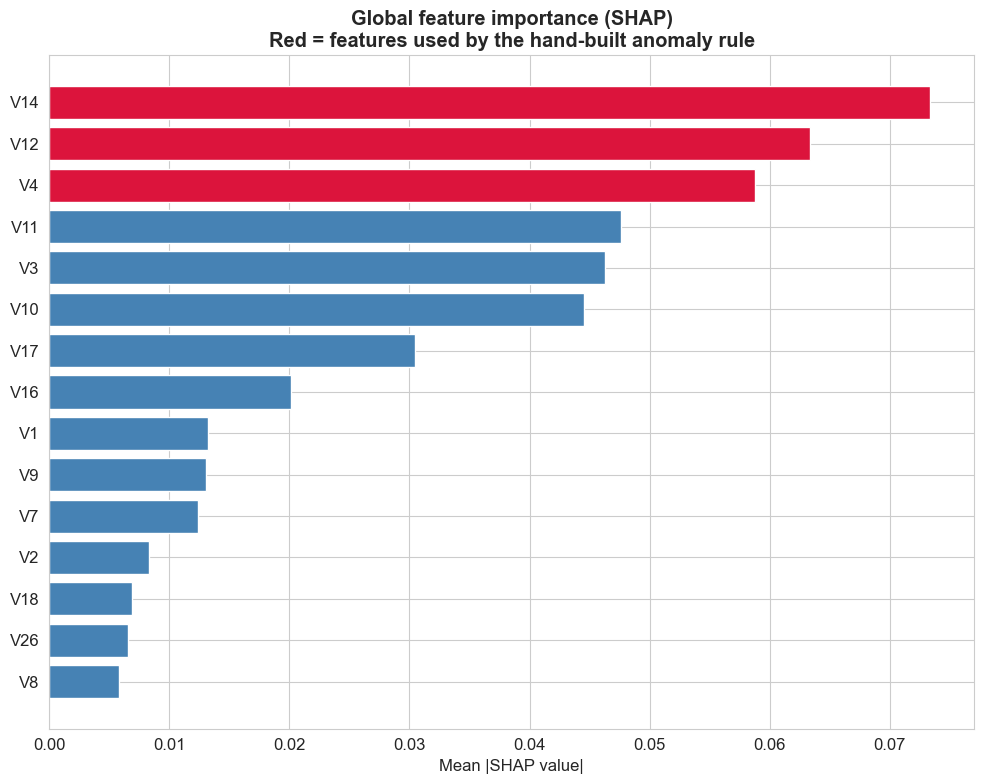

In [14]:
mean_abs = pd.Series(np.abs(shap_fraud).mean(axis=0), index=feature_cols)\
            .sort_values(ascending=False)

print('Top 15 features by mean |SHAP| (global importance)')
print('=' * 55)
for i, (feat, val) in enumerate(mean_abs.head(15).items(), 1):
    marker = '  <-- used by the anomaly rule' if feat in ('V14', 'V4', 'V12') else ''
    print(f'{i:>3}. {feat:<14} {val:.5f}{marker}')

fig, ax = plt.subplots(figsize=(10, 8))
top = mean_abs.head(15).sort_values()
colors = ['crimson' if f in ('V14','V4','V12') else 'steelblue' for f in top.index]
ax.barh(top.index, top.values, color=colors, edgecolor='white')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global feature importance (SHAP)\nRed = features used by the hand-built anomaly rule',
             fontweight='bold')
plt.tight_layout(); plt.savefig('plots/shap_global.png', dpi=150, bbox_inches='tight'); plt.show()

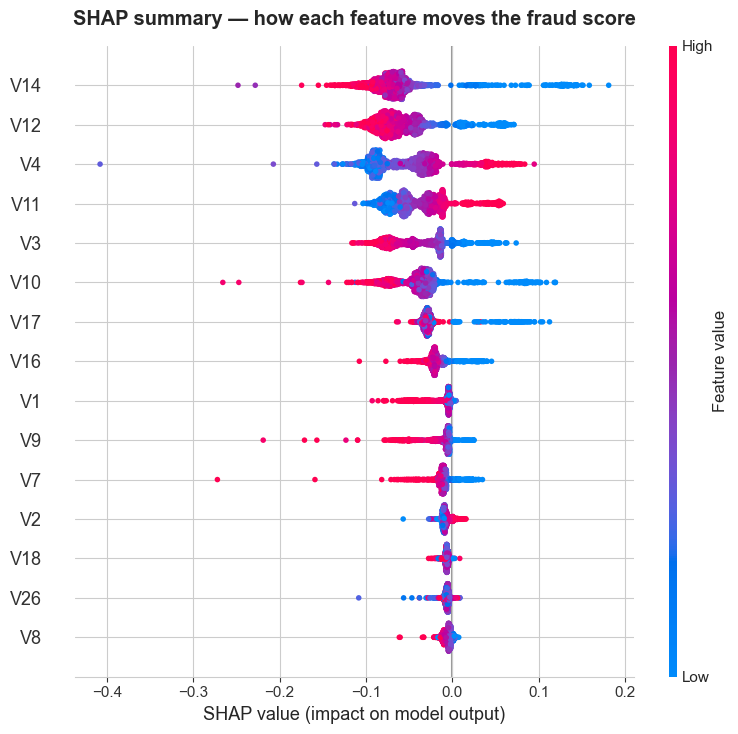

In [15]:
# Beeswarm: direction as well as magnitude
shap.summary_plot(shap_fraud, X_sample, feature_names=feature_cols,
                  max_display=15, show=False)
plt.title('SHAP summary — how each feature moves the fraud score', fontweight='bold', pad=15)
plt.tight_layout(); plt.savefig('plots/shap_beeswarm.png', dpi=150, bbox_inches='tight'); plt.show()

## Step 3: Does SHAP agree with the hand-built rule?

The anomaly rule was built on V14, V4 and V12 from visual inspection of the EDA. The
model was trained independently and never told about that choice. If SHAP ranks those
three highly, two independent methods agree — which is meaningfully stronger evidence
than either alone.

In [16]:
rule_features = ['V14', 'V4', 'V12']
ranks = {f: int(list(mean_abs.index).index(f)) + 1 for f in rule_features}

print('Where the rule features land in the model\'s own ranking:')
for f in rule_features:
    print(f'  {f:<5} rank {ranks[f]:>2} of {len(feature_cols)}')

avg_rank = np.mean(list(ranks.values()))
print()
if avg_rank <= 8:
    print(f'Average rank {avg_rank:.1f} — strong agreement. The EDA-driven feature choice is')
    print('independently corroborated by the model. Worth saying in an interview: two')
    print('methods, one visual and one model-derived, converged on the same features.')
else:
    print(f'Average rank {avg_rank:.1f} — weaker agreement than expected. The rule may be')
    print('leaving signal on the table; features the model favours are worth testing as')
    print('additional rule components.')

print()
print(f'Top 5 features the rule does NOT use: '
      f'{[f for f in mean_abs.head(8).index if f not in rule_features][:5]}')
print('These are the natural candidates for a fourth rule component.')

Where the rule features land in the model's own ranking:
  V14   rank  1 of 30
  V4    rank  3 of 30
  V12   rank  2 of 30

Average rank 2.0 — strong agreement. The EDA-driven feature choice is
independently corroborated by the model. Worth saying in an interview: two
methods, one visual and one model-derived, converged on the same features.

Top 5 features the rule does NOT use: ['V11', 'V3', 'V10', 'V17', 'V16']
These are the natural candidates for a fourth rule component.


## Step 4: Local attribution — explaining one transaction

This is the part an analyst sees. For a single flagged transaction: which features drove
the score, in which direction, and by how much.

In [17]:
# Pick the highest-confidence true positive as a worked example
tp_mask = (proba_te >= 0.5) & (y_te.values == 1)
example_pos = int(np.argmax(np.where(tp_mask, proba_te, -1)))
sample_pos  = int(np.where(sample_idx == example_pos)[0][0])

print(f'Transaction ID   : {id_te.iloc[example_pos]}')
print(f'Amount           : EUR {amt_te.iloc[example_pos]:,.2f}')
print(f'Actual class     : {"FRAUD" if y_te.values[example_pos]==1 else "legitimate"}')
print(f'Model confidence : {proba_te[example_pos]:.4f}')
print()

contrib = pd.Series(shap_fraud[sample_pos], index=feature_cols).sort_values(key=abs, ascending=False)
print('Top 10 contributions to this prediction:')
print(f"{'feature':<14} {'value':>10} {'SHAP':>10}  effect")
for feat, s in contrib.head(10).items():
    print(f'{feat:<14} {X_sample.iloc[sample_pos][feat]:>10.3f} {s:>10.5f}  '
          f'{"pushes toward FRAUD" if s > 0 else "pushes toward legitimate"}')

Transaction ID   : 15811
Amount           : EUR 99.99
Actual class     : FRAUD
Model confidence : 1.0000

Top 10 contributions to this prediction:
feature             value       SHAP  effect
V14                -6.326    0.12632  pushes toward FRAUD
V10                -8.234    0.08427  pushes toward FRAUD
V17               -12.062    0.07210  pushes toward FRAUD
V4                  6.378    0.06882  pushes toward FRAUD
V12                -6.526    0.05873  pushes toward FRAUD
V11                 4.665    0.05509  pushes toward FRAUD
V3                -27.369    0.05001  pushes toward FRAUD
V16                -5.838    0.02919  pushes toward FRAUD
V9                 -3.743    0.02319  pushes toward FRAUD
V7                -18.261    0.02188  pushes toward FRAUD


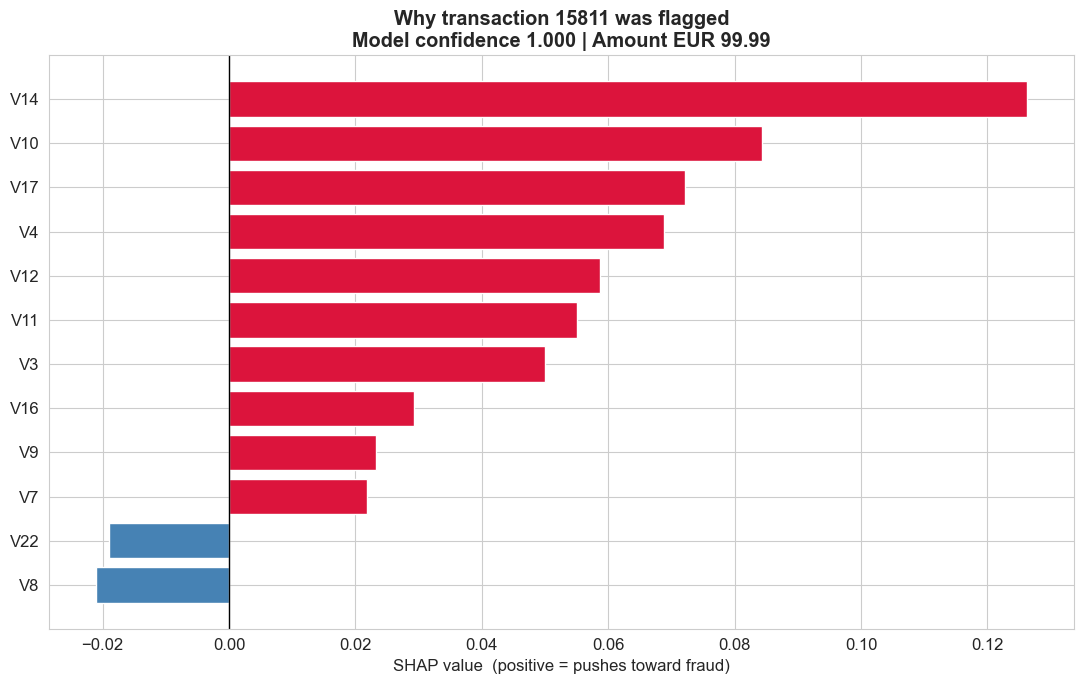

In [18]:
fig, ax = plt.subplots(figsize=(11, 7))
top_c = contrib.head(12).sort_values()
ax.barh(top_c.index, top_c.values,
        color=['crimson' if v > 0 else 'steelblue' for v in top_c.values],
        edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('SHAP value  (positive = pushes toward fraud)')
ax.set_title(f'Why transaction {id_te.iloc[example_pos]} was flagged\n'
             f'Model confidence {proba_te[example_pos]:.3f} | '
             f'Amount EUR {amt_te.iloc[example_pos]:,.2f}',
             fontweight='bold')
plt.tight_layout(); plt.savefig('plots/shap_single_prediction.png', dpi=150, bbox_inches='tight'); plt.show()

## Step 5: The analyst-facing output

SHAP arrays are not what an operations team should receive. This turns attributions into
a plain-language explanation attached to each alert — the artefact that decides whether
the model gets adopted or ignored.

Note the deliberate honesty in the wording: the features are PCA components, so we can
say *which* signal is anomalous and *how strongly*, but never *what it means*. Claiming
otherwise would be fabrication.

In [19]:
def explain_alert(i, top_n=3):
    """Plain-language explanation for one flagged transaction."""
    s_pos = np.where(sample_idx == i)[0]
    if len(s_pos) == 0:
        return None
    s_pos = int(s_pos[0])
    c = pd.Series(shap_fraud[s_pos], index=feature_cols).sort_values(ascending=False)
    drivers = c.head(top_n)

    conf = proba_te[i]
    band = 'HIGH' if conf >= 0.8 else 'MEDIUM' if conf >= 0.4 else 'LOW'
    reasons = [f'{f} = {X_sample.iloc[s_pos][f]:.2f} (contribution {v:+.3f})'
               for f, v in drivers.items()]

    return {
        'transaction_id': int(id_te.iloc[i]),
        'amount_eur':     round(float(amt_te.iloc[i]), 2),
        'confidence':     round(float(conf), 4),
        'priority':       band,
        'top_drivers':    ' | '.join(reasons),
        'actual_class':   int(y_te.values[i]),
    }

flagged = np.where(proba_te >= 0.125)[0]                 # cost-optimal threshold
in_sample = [i for i in flagged if i in set(sample_idx)]
queue = pd.DataFrame([r for r in (explain_alert(i) for i in in_sample[:15]) if r])
queue = queue.sort_values('confidence', ascending=False)

print(f'Analyst review queue — {len(queue)} sample alerts at threshold 0.125')
print('=' * 118)
for _, r in queue.head(6).iterrows():
    verdict = 'CONFIRMED FRAUD' if r['actual_class'] == 1 else 'false positive'
    print(f"\n[{r['priority']}] Transaction {r['transaction_id']} — EUR {r['amount_eur']:,.2f} "
          f"(confidence {r['confidence']:.3f})")
    print(f"  Flagged because: {r['top_drivers']}")
    print(f"  Ground truth (not shown to analyst in production): {verdict}")

print()
print('Caveat stated rather than hidden: V1-V28 are PCA components, so an explanation')
print('can identify WHICH latent signal is anomalous and HOW strongly, but never WHAT it')
print('represents. On non-anonymised data these map to real attributes and the same')
print('output becomes directly actionable.')

Analyst review queue — 15 sample alerts at threshold 0.125

[HIGH] Transaction 102443 — EUR 1.00 (confidence 0.980)
  Flagged because: V14 = -9.07 (contribution +0.125) | V10 = -5.05 (contribution +0.078) | V17 = -6.25 (contribution +0.077)
  Ground truth (not shown to analyst in production): CONFIRMED FRAUD

[HIGH] Transaction 141261 — EUR 512.25 (confidence 0.980)
  Flagged because: V14 = -12.88 (contribution +0.130) | V10 = -8.34 (contribution +0.090) | V17 = -12.72 (contribution +0.068)
  Ground truth (not shown to analyst in production): CONFIRMED FRAUD

[HIGH] Transaction 151520 — EUR 1.63 (confidence 0.970)
  Flagged because: V14 = -7.01 (contribution +0.108) | V10 = -16.26 (contribution +0.078) | V17 = -16.67 (contribution +0.077)
  Ground truth (not shown to analyst in production): CONFIRMED FRAUD

[HIGH] Transaction 153836 — EUR 1.00 (confidence 0.970)
  Flagged because: V14 = -3.84 (contribution +0.084) | V17 = -15.83 (contribution +0.077) | V10 = -20.95 (contribution +0.077

## Step 6: Persist

In [20]:
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv(override=True)
engine = create_engine(
    f"postgresql://{os.getenv('DB_USER','postgres')}:{os.getenv('DB_PASS')}"
    f"@{os.getenv('DB_HOST','localhost')}:{os.getenv('DB_PORT','5432')}/{os.getenv('DB_NAME','fraud_detection')}"
)

importance = mean_abs.reset_index()
importance.columns = ['feature', 'mean_abs_shap']
importance['rank'] = range(1, len(importance) + 1)
importance['used_by_rule'] = importance['feature'].isin(rule_features)

importance.to_sql('shap_feature_importance', engine, if_exists='replace', index=False)
queue.to_sql('alert_explanations', engine, if_exists='replace', index=False)
print('Written to PostgreSQL: shap_feature_importance, alert_explanations')

Written to PostgreSQL: shap_feature_importance, alert_explanations


---

## Summary

**The model is now as reviewable as the rules.** Every flag carries its top contributing
features and their direction, which is the precondition for an operations team trusting
it enough to work the queue.

**Convergent validation of the feature selection.** The anomaly rule's V14/V4/V12 were
chosen from EDA; the model was trained independently. Where SHAP ranks those features
highly, two methods agree — and any high-ranking feature the rule *doesn't* use is a
ready-made candidate for a fourth component.

**Honest about what explainability can deliver here.** PCA-anonymised features mean SHAP
identifies which latent signal fired and how hard, never what it means. That limit is
stated in the output rather than papered over.

### Limitations

- TreeSHAP is exact but expensive; this samples rather than explaining all 56,962 rows
- SHAP shows association within the model, not causation in the world
- Explanations are only as trustworthy as the model — a well-explained wrong prediction
  is still wrong, and fluent explanations can increase misplaced confidence
- On PCA features the analyst-facing text is illustrative rather than genuinely
  actionable